# Example Spectrum Analysis

The purpose of this notebook is to document an example of how to use Spyctre to analyse a spectrum and determine the spectral type of the star.  It is based on an example script by Etienne Bachelet. 

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
import scipy.optimize as so

# Spyctres uses the Stsynphot libraries of stellar spectral templates for its analysis.
# The local installation path needs to be declared before the package is imported. 
os.environ['PYSYN_CDBS'] =  '/data/cdbs/'

import speclite.filters
import speclite
from astropy.io import fits
import astropy.units as u
import astropy.constants as constantes
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time

from Spyctres import Spyctres
import stsynphot

## Data Input

First we load the observed, extracted and wavelength calibrated spectrum.  Note that the expectation is for uncertainties on the flux measurements which are not always provided by spectroscopic reduction pipelines.  Here this column is filled with 1.0 instead. 

In [ ]:
output_dir = '/data/OMEGAII/data_reduction/OGLE-2024-BLG-0034/SOAR/2025-04-23'
file_name = 'wecfzst_03160317_OGLE-2024-BLG-0034_SOAR_2_23-04-2025_target_1_ws_1.csv'

In [ ]:
spec_file = os.path.join(output_dir, file_name)
spectrum_timestamp = Time(2460788.693284375, format='jd') # 2025-04-23T04:38:19.770'
spectrum = np.loadtxt(spec_file, delimiter=' ', skiprows=3)
spectrum  = np.c_[spectrum[:,0], spectrum[:,1], np.array([1.0]*len(spectrum))]

In [ ]:
fig, ax = plt.subplots(1, 1)
#ax.set_yscale('log')
ax.plot(spectrum[:,0], spectrum[:,1], ls='-', c='purple', label='Data')
ax.set_xlabel(r'$\lambda [\AA]$')
ax.set_ylabel(r'$F_\lambda [erg/s/cm^2/\AA]$')

Spyctre can analyze multiple spectra at once, corresponding to source at different lensing magnifications.  As a result, the flux values of each spectrum need too be scaled by the magnification at the time of observation.  This information is provided as a dictionary as follows. 

In [ ]:
coord = SkyCoord(ra=266.04333*u.degree, dec=-39.11322*u.degree, frame='icrs')
spectrum_timestamp = Time(2460788.693284375, format='jd') # 2025-04-23T04:38:19.770'

spectra = {}
spectra['SOAR_2024_07_02'] = {}
spectra['SOAR_2024_07_02']['spectrum'] = spectrum
spectra['SOAR_2024_07_02']['JD'] = spectrum_timestamp
spectra['SOAR_2024_07_02']['magnification'] = 2.5
spectra['SOAR_2024_07_02']['barycentric_velocity']  = Spyctres.Barycentric_velocity(spectra['SOAR_2024_07_02']['JD'],coord)

Since flux standards aren't always available, many spectroscopic observations are not in calibrated flux units.  Spectre uses calibrated photometry to normalise the observations.  This works best if calibrated magnitudes are provided in multiple passbands across the wavelength range of the spectrum.  These are included in the dictionary together with the passband information for the corresponding filters.  The speclite package includes some pre-defined information on common filter sets. 

In [ ]:
twomass_filters = speclite.filters.load_filters('twomass-J', 'twomass-H', 'twomass-Ks')
sdss_filters = speclite.filters.load_filters('sdss2010-*')
bessel_filters = speclite.filters.load_filters('bessell-*')
gaia_filters = speclite.filters.load_filters('gaiadr2-*')

# Filters from each set can be referred to from their index in each list, e.g.:
sdss_filters.names

In [ ]:
# Define magnitudes of the source in the different filter passbands as lists of the form:
# [filter, magnitude, mag error]
spectra['SOAR_2024_07_02']['SED'] = [
    [sdss_filters[1], 18.3, 0.1],       # SDSS-g centre ~ 450nm
    [bessel_filters[4], 16.2, 0.02],    # Bessel-I centre ~ 800nm
    [sdss_filters[3], 16.59, 0.08],     # SDSS-i centre ~ 750nm
]

Spyctre can now use these photometric measurements to estimate the offset in flux between the measured spectrum and the model. 

In [ ]:
offset1 = Spyctres.SED_offset(np.array(spectra['SOAR_2024_07_02']['SED']), spectrum)

## Finding the best-fit template spectrum

We can now use Spyctre to explore a range of model template spectra and find the model that best fits the data.  It uses a Differential Evolution approach to exploring the parameter space, so we first need to define the boundary conditions of the stellar spectrum models to be fitted:

In [ ]:
# From Spyctres.model_spectra and fit_spectra methods, parameter order expected is:
# theta_s, Av, v_radial, log10_teff, abundance, logg, followed by normalization factors for each spectra
bound = [
    [-2,2],     # log10(theta_*)
    [1,4],      # Av
    [-2000,2000],   # RV in km/s
    [3,4],      # log(Teff)
    [-0.9,-0.3],    # Metallicity
    [3.5,5.0],      # log(g)
    [np.log10(0.5*offset1[0]),np.log10(1.5*offset1[0])], # Offset flux factor to match SEC (log10) for spectrum 1
    [0.01, 0.1],# Error bar rescaling for spectrum 1
]

Since Earth-based spectra will also contain telluric lines due to water vapour in the Earth's atmosphere, we also need to provide a mask for those lines in the spectrum.  Spyctre provides a library of these lines. 

In [ ]:
# Find telluric lines; the argument is the limit on absorption fraction.  90% masks everything above that level
telluric_lines, telluric_mask = Spyctres.load_telluric_lines(0.90)

Now we can run the DE model fitting process, using Spyctre's built-in method for calculating the chi^2 of the model spectrum fit to the data as the merit function.

In [ ]:
res = so.differential_evolution(
    Spyctres.fit_spectra_chichi,
    bound,
    args=(spectra, telluric_mask, 'k93models'),
    disp=True,
    popsize=4,
    workers=1,
    polish=False
)
print('RESULTS: ', res)

The results array contains the stellar spectral parameters of the best-fit model (res.x) in the same parameter order as used for the bound conditions.  Extracting these results, we can generate a model spectrum of the best-fit model. 

In [ ]:
print('Theta_*: ' + str(res.x[0]))
print('Av: ' + str(res.x[1]) + 'mag')
print('RV: ' + str(res.x[2]) + 'km/s')
print('Teff: ' + str(10**(res.x[3])) + 'K')
print('Abundance: ' + str(res.x[4]))
print('log(g): ' + str(res.x[5]))

In [ ]:
momo = Spyctres.model_spectra(res.x, spectra)

Before we can compare this with the data, we need to rescale the model template fluxes to match those observed.

In [ ]:
for i in range(len(spectra)):
    rescale_flux_parameter = res.x[6+i]
    rescale_flux = 10**rescale_flux_parameter
    momo[i][:,1] /= rescale_flux

In [ ]:
fig, ax = plt.subplots(1,1)
ax.set_yscale('log')
xmin, xmax = ax.get_xlim()
ax.errorbar(spectrum[:,0], spectrum[:,1], spectrum[:,2],fmt='.', c='blue', label='Data')
ax.fill_between(spectrum[:,0], xmin, xmax, where=telluric_mask(spectrum[:,0]), color='grey', alpha=0.25)
ax.plot(momo[0][:,0],momo[0][:,1], c='black', label='Model')
ax.set_xlabel(r'$\lambda [\AA]$')
ax.set_ylabel(r'$F_\lambda [erg/s/cm^2/\AA]$')
ax.set_title('Fitted spectrum')
ax.legend()
(xmin, xmax) = ax.get_xlim()
ax.set_xlim([xmin, 10000.0])
(ymin, ymax) = ax.get_ylim()
ax.set_ylim([200, ymax])

## Output results

It is helpful to store the scaled data spectrum and model for future reference.

In [ ]:
with open(os.path.join(output_dir, 'scaled_data_spectrum.txt'), 'w') as f:
    f.write('# Wavelength [A]   Flux [scaled]\n')
    for i in range(0, len(spectrum), 1):
        f.write(str(spectrum[i,0]) + ' ' + str(spectrum[i,1]) + ' ' + str(spectrum[i,2]) + '\n')
    f.close()

In [ ]:
with open(os.path.join(output_dir, 'model_spectrum.txt'), 'w') as f:
    f.write('# Wavelength [A]   Flux [scaled]\n')
    for i in range(0, len(momo[0]), 1):
        f.write(str(momo[0][i,0]) + ' ' + str(momo[0][i,1]) + '\n')
    f.close()

In [ ]:
with open(os.path.join(output_dir, 'de_results.txt'), 'w') as f:
    f.write(repr(res.x) + '\n')
    f.write('NIT ' + str(res.nit) + '\n')
    f.write('Population ' + repr(res.population))
    f.write('Population energies ' + repr(res.population_energies))
    f.close()

## Simulating a generic stellar spectrum

In [20]:
teff = 5300
logg = 4.5
abundance = 0.0
catalog = 'k93models'

model_spectrum = stsynphot.grid_to_spec(catalog, teff, abundance, logg)
model_spectrum

In [24]:
wave = np.arange(3000, 25000, 1.0)
flux = model_spectrum(wave*u.AA) * 1.98644746*10**-8/wave

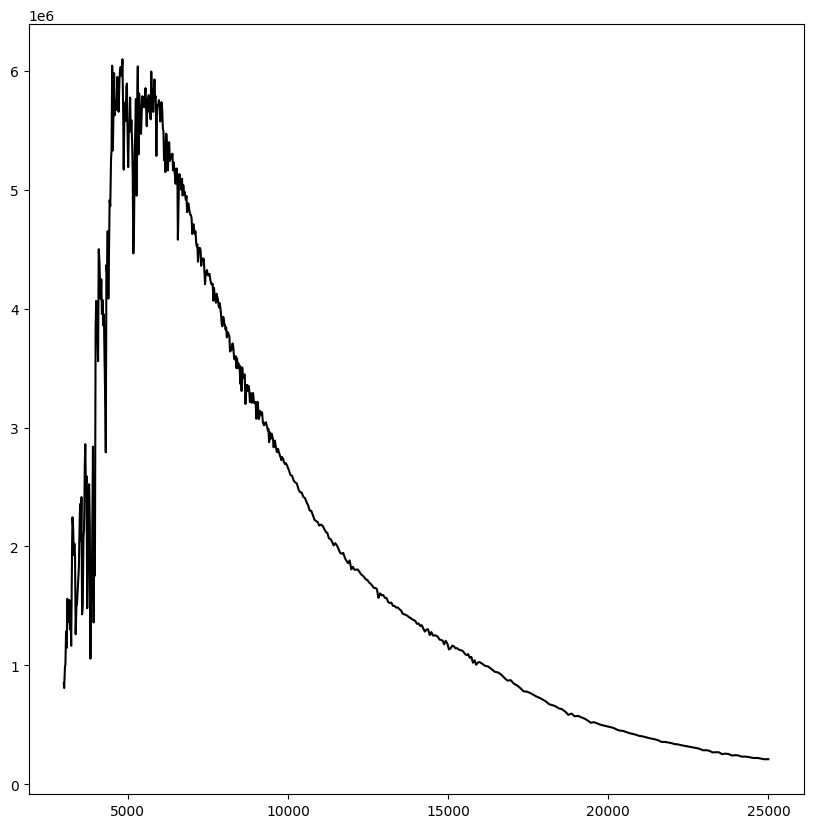

In [25]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.plot(wave, flux, 'k-')

In [26]:
with open(os.path.join('/data/OMEGAII/data_reduction/OGLE-2024-BLG-0034/SOAR/2025-04-23', 'example_mdwarf_spectrum.txt'), 'w') as f:
    f.write('# Wavelength [A]   Flux [scaled]\n')
    for i in range(0, len(wave), 1):
        f.write(str(wave[i]) + ' ' + str(flux[i].value) + '\n')
    f.close()